# Tutorial 2 · From microwave-link signal to rain rate

**What this notebook covers.** The physics that makes a commercial microwave link (CML)
a rain gauge, and the processing chain that turns its received power into a rain rate:
total loss, quality control, wet/dry classification, baseline, wet-antenna correction
and the k-R power law. Each step is run on one OpenMRG link during the storm of
25 July 2015 and checked against the radar along the path and the nearest gauge; at the
end the whole chain runs on all 364 links.

**Prerequisites.** [Tutorial 1](01_open_data.ipynb) (the data). Runs in about a minute
on the OpenMRG example subset.

**Contents**
1. Why rain attenuates a microwave signal
2. One link, raw
3. Total loss and quality control
4. Wet or dry?
5. Baseline
6. Wet-antenna attenuation
7. Rain rate, and how it compares
8. The whole network
9. Where this is used in FieldSense
10. References and links

## 1. Why rain attenuates a microwave signal

Raindrops absorb and scatter microwave radiation. Above about 10 GHz the drops are no
longer small compared with the wavelength, and the *specific attenuation* k (dB/km)
becomes a near power law of the rain rate R (mm/h):

$$k = a\,R^{\,b}$$

with coefficients a and b that depend on frequency and polarization, tabulated by the
ITU in Recommendation [ITU-R P.838-3](https://www.itu.int/rec/R-REC-P.838-3-200503-I/en).
A link of length L that sees rain-induced attenuation $A$ (dB) therefore measures the
**path-averaged** rain rate

$$R = \left(\frac{A}{a\,L}\right)^{1/b}.$$

Two properties matter in practice. Near 20-40 GHz, b is close to 1, so the relation is
almost linear and the path average of k is close to k of the path-average rain - the
reason CMLs measure areal rain well (Atlas & Ulbrich, 1977; Leijnse et al., 2008). And
the signal a link reports also contains everything that is not rain - the free-space
loss, gaseous absorption, hardware drift, wet antennas - which the processing chain
below must remove. `core.cml.power_law` implements the ITU table:

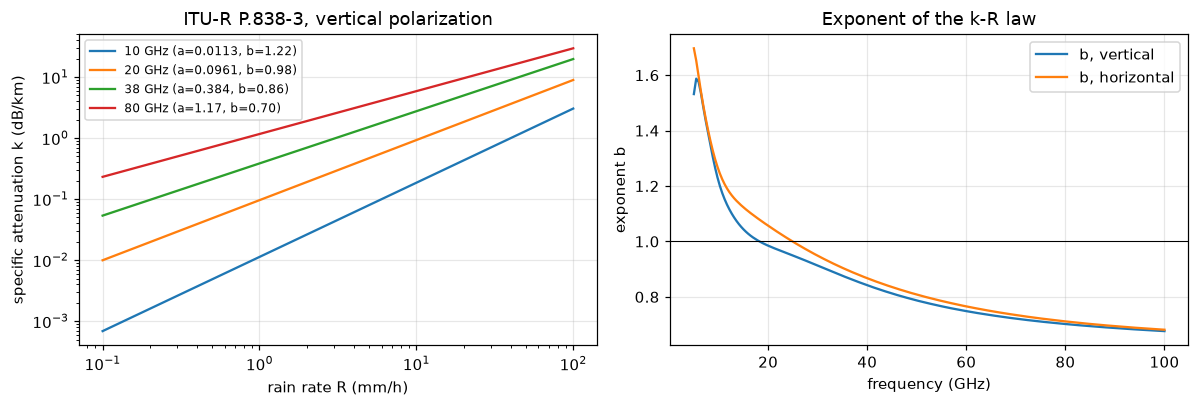

In [1]:
import contextlib
import io
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from core.cml.power_law import itu_ab
from core.opensense import example_data

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

R = np.logspace(-1, 2, 100)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for f in [10, 20, 38, 80]:
    a, b = (float(v[0]) for v in itu_ab(f, "v"))
    axes[0].loglog(R, a * R ** b, label=f"{f} GHz (a={a:.3g}, b={b:.2f})")
axes[0].set(xlabel="rain rate R (mm/h)", ylabel="specific attenuation k (dB/km)",
            title="ITU-R P.838-3, vertical polarization")
axes[0].legend(fontsize=8)
freqs = np.linspace(5, 100, 200)
axes[1].plot(freqs, itu_ab(freqs, "v")[1], label="b, vertical")
axes[1].plot(freqs, itu_ab(freqs, "h")[1], label="b, horizontal")
axes[1].axhline(1, color="k", lw=0.7)
axes[1].set(xlabel="frequency (GHz)", ylabel="exponent b", title="Exponent of the k-R law")
axes[1].legend()
plt.tight_layout()

A 2 km link at 38 GHz in 10 mm/h of rain loses about `2 * a * 10**b` dB:

In [2]:
a, b = (float(v[0]) for v in itu_ab(38, "v"))
print(f"38 GHz, 2 km, 10 mm/h -> A = {2 * a * 10 ** b:.1f} dB")

38 GHz, 2 km, 10 mm/h -> A = 5.5 dB


## 2. One link, raw

OpenMRG records the transmitted (TSL) and received (RSL) signal level of both
directions of every link every 10 seconds. We take two days - a dry day for the
baseline and the storm day - and the radar and gauges for the same window.

link 10067: 2.87 km, [28.1785 29.1865] GHz, ['horizontal' 'horizontal']


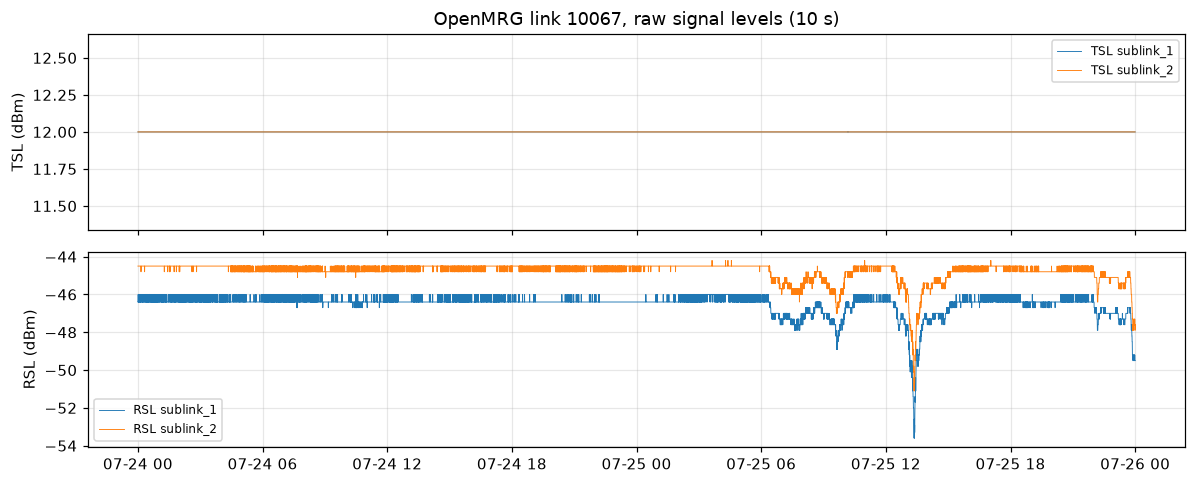

In [3]:
with contextlib.redirect_stdout(io.StringIO()):
    data = example_data.load("openmrg", "8d", time=slice("2015-07-24", "2015-07-25"))
cml_10s, radar, gauges = data["cml"], data["radar"], data["gauge_municipal"]

LINK = 10067      # 2.9 km, 28 GHz, about 1 km from the Askim gauge
link = cml_10s.sel(cml_id=LINK)
print(f"link {LINK}: {float(link.length_km):.2f} km, "
      f"{link.frequency_ghz.values} GHz, {link.polarization.values}")

fig, axes = plt.subplots(2, 1, figsize=(11, 4.5), sharex=True)
for s in link.sublink_id.values:
    axes[0].plot(link.time, link.tsl.sel(sublink_id=s), lw=0.6, label=f"TSL {s}")
    axes[1].plot(link.time, link.rsl.sel(sublink_id=s), lw=0.6, label=f"RSL {s}")
axes[0].set_ylabel("TSL (dBm)"); axes[1].set_ylabel("RSL (dBm)")
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
axes[0].set_title(f"OpenMRG link {LINK}, raw signal levels (10 s)")
plt.tight_layout()

The received level drops by several dB on 25 July - that is the rain. On this link
the transmitted level stays at 12 dBm throughout, but many links use automatic
transmit power control, which raises TSL when the link fades. That is why the loss
is computed as TSL - RSL wherever TSL is recorded (OpenMesh records RSL only, see
`core.cml.preprocess.total_loss`). The two directions sit at different levels: only
changes in loss carry the rain signal, and the baseline step removes the level.

The OpenSense processing chain works at 1-minute resolution. Averaging the 10-s samples
to 1 minute also reduces the quantization noise (RSL is reported in steps of 0.1-1 dB).

In [4]:
cml = cml_10s[["tsl", "rsl"]].resample(time="1min").mean()
cml = cml.assign_coords({c: cml_10s[c] for c in cml_10s.coords if "time" not in cml_10s[c].dims})
cml = cml.transpose("cml_id", "sublink_id", "time")
cml

<xarray.Dataset> Size: 34MB
Dimensions:        (time: 2880, sublink_id: 2, cml_id: 364)
Coordinates: (12/18)
    site_0_lat     (cml_id) float64 3kB 57.7 57.73 57.69 ... 57.65 57.66 57.71
    site_0_lon     (cml_id) float64 3kB 12.0 11.98 11.97 ... 12.12 12.03 12.01
    site_1_lat     (cml_id) float64 3kB 57.7 57.72 57.69 ... 57.66 57.63 57.71
    site_1_lon     (cml_id) float64 3kB 11.99 11.97 11.98 ... 12.14 11.97 11.98
    frequency      (cml_id, sublink_id) float64 6kB 2.821e+04 ... 2.926e+04
    polarization   (cml_id, sublink_id) <U10 29kB 'vertical' ... 'vertical'
    ...             ...
    site_1_y       (cml_id) float64 3kB 6.399e+06 6.402e+06 ... 6.401e+06
    x              (cml_id) float64 3kB 6.784e+05 6.773e+05 ... 6.785e+05
    y              (cml_id) float64 3kB 6.399e+06 6.402e+06 ... 6.4e+06
  * time           (time) datetime64[ns] 23kB 2015-07-24 ... 2015-07-25T23:59:00
  * sublink_id     (sublink_id) <U9 72B 'sublink_1' 'sublink_2'
  * cml_id         (cml_id) int64 3kB 10001 10002 10003 ... 10362 10363 10364
Data variables:
    tsl            (cml_id, sublink_id, time) float64 17MB 1.0 1.0 ... 0.0 0.0
    rsl            (cml_id, sublink_id, time) float64 17MB -46.0 ... -49.25
Attributes: (12/14)
    title:                 OpenMRG-CML
    version:               1.1
    source:                Swedish Meteorological and Hydrological Institute ...
    contact:               hydro.fou@smhi.se, jafet.andersson@smhi.se
    license:               https://creativecommons.org/licenses/by-sa/4.0
    doi:                   https://doi.org/10.5281/zenodo.6673750
    ...                    ...
    institution:           NA
    date:                  NA
    history:               NA
    naming convention:     NA
    license restrictions:  NA
    reference:             NA

## 3. Total loss and quality control

The total loss TL = TSL - RSL is the quantity every later step works on. Before using
it, links that cannot be trusted are removed. We use the quality control of the
OpenSense radar-adjustment intercomparison
([OpenSenseAction/radar_adjustment_intercomparison](https://github.com/OpenSenseAction/radar_adjustment_intercomparison)),
implemented in `core.opensense.intercomparison_chain.preprocess`:

* **spikes**: where the two channels of a link differ by more than 30 dB, the higher
  one is set to missing;
* **diurnal cycle**: the 5-h rolling standard deviation of TL exceeds 2 dB more than 10%
  of the time - typical of links affected by temperature or multipath;
* **noisy**: the 1-h standard deviation exceeds 0.8 dB more than 35% of the time;
* **flat**: the 1-h standard deviation exceeds 0.8 dB less than 1% of the time - a link
  that never fluctuates also never sees rain.

These thresholds are computed over the whole window, so the QC needs a long record (the
intercomparison runs it on three months); on two days it is only an illustration.

In [5]:
from core.opensense import intercomparison_chain as ic

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kept, removed = ic.preprocess(cml)
print(f"{removed.sizes['cml_id']} of {cml.sizes['cml_id']} links have at least one flagged channel "
      f"(a flagged channel is set to missing); {cml.sizes['cml_id'] - kept.sizes['cml_id']} are dropped "
      f"because both channels are flagged; {kept.sizes['cml_id']} remain")
print("link", LINK, "kept" if LINK in kept.cml_id.values else "removed")

70 of 364 links have at least one flagged channel (a flagged channel is set to missing); 46 are dropped because both channels are flagged; 318 remain
link 10067 kept


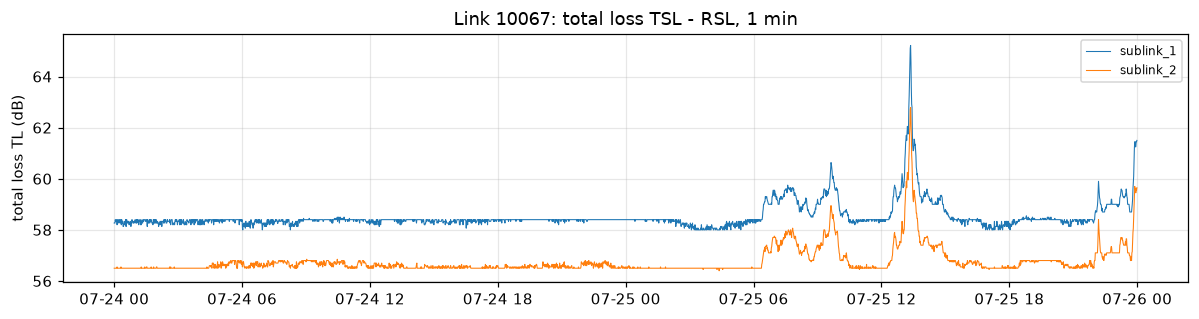

In [6]:
tl = kept.tl.sel(cml_id=LINK)
fig, ax = plt.subplots(figsize=(11, 3))
for s in tl.sublink_id.values:
    ax.plot(tl.time, tl.sel(sublink_id=s), lw=0.7, label=s)
ax.set(ylabel="total loss TL (dB)", title=f"Link {LINK}: total loss TSL - RSL, 1 min")
ax.legend(fontsize=8)
plt.tight_layout()

## 4. Wet or dry?

The baseline - the loss the link would have in dry weather - can only be estimated
from dry periods, so each minute must first be classified wet or dry. Two classifiers:

* **Rolling standard deviation** (Schleiss & Berne, 2010): rain makes the signal
  fluctuate, so a window whose standard deviation exceeds a threshold is wet. It needs
  only the link itself. `core.opensense.retrieval.wet_dry_rolling_std`, here with a
  30-min window; the threshold is examined below.
* **Radar along the path** (the intercomparison's choice): a minute is wet when the
  radar sees more than 0.01 mm along the path in the radar step containing it, or in
  the 5 minutes after. Accurate where the radar is good, but it makes the links depend
  on the radar - a problem for a study that then compares links with that radar.

Other options in FieldSense are the nearby-link method (Overeem et al., 2016;
`core.opensense.wet_dry.nearby_links`) and a convolutional network (Polz et al., 2020;
`core.opensense.wet_dry.cnn`).

In [7]:
from core.opensense.retrieval import wet_dry_rolling_std

# radar along every path: poligrain intersect weights on the radar grid (Tutorial 4)
radar_along = ic.radar_along_links(radar.R * 5 / 60, kept, radar.lon.values, radar.lat.values)  # mm per 5 min

wet_radar = ic.wet_from_radar(kept, radar_along, rad_freq=5).sel(cml_id=LINK)
tl_link = kept.tl.sel(cml_id=LINK).transpose("time", "sublink_id").values
radar_wet = wet_radar.isel(sublink_id=0).values.astype(bool)

rows = []
for window in [15, 30, 60]:
    for threshold in [0.2, 0.4, 0.8]:
        w = wet_dry_rolling_std(tl_link, window, threshold)[:, 0]
        rows.append({"window (min)": window, "threshold (dB)": threshold,
                     "radar-wet minutes found wet": w[radar_wet].mean(),
                     "radar-dry minutes called wet": w[~radar_wet].mean()})
pd.DataFrame(rows).set_index(["window (min)", "threshold (dB)"]).style.format("{:.1%}")

Taking the radar as the reference, the rolling-std classifier trades misses against
false alarms through its window and threshold, and no single setting fits every link:
a short link that sees only a few dB during a storm needs a lower threshold than a
long one, and a lower threshold calls more dry minutes wet. Below, 30 min and 0.4 dB
against the radar mask:

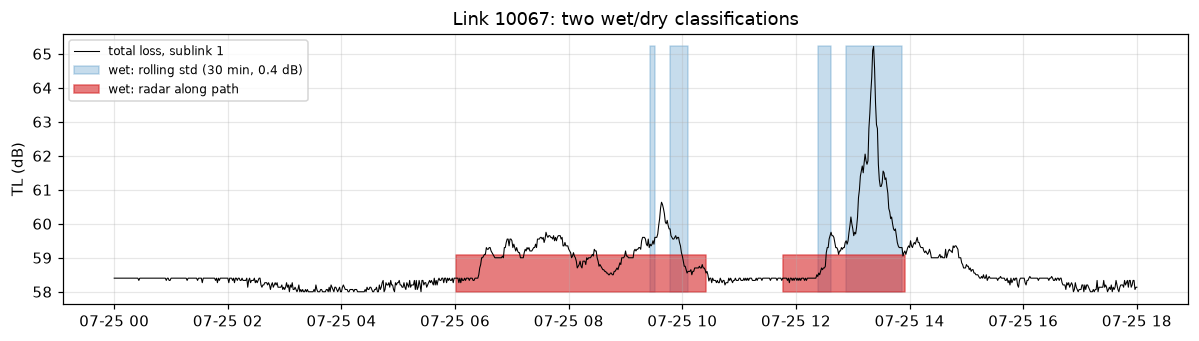

In [8]:
wet_std = xr.DataArray(wet_dry_rolling_std(tl_link, 30, 0.4), dims=("time", "sublink_id"),
                       coords={"time": kept.time, "sublink_id": kept.sublink_id})

fig, ax = plt.subplots(figsize=(11, 3.2))
day = slice("2015-07-25 00:00", "2015-07-25 18:00")
t = tl.sel(sublink_id=tl.sublink_id[0], time=day)
ax.plot(t.time, t, color="k", lw=0.7, label="total loss, sublink 1")
lo, hi = float(t.min()), float(t.max())
ax.fill_between(t.time, lo, hi, where=wet_std.isel(sublink_id=0).sel(time=day).values,
                color="C0", alpha=0.25, label="wet: rolling std (30 min, 0.4 dB)")
ax.fill_between(t.time, lo, lo + (hi - lo) * 0.15, where=wet_radar.isel(sublink_id=0).sel(time=day).values,
                color="C3", alpha=0.6, label="wet: radar along path")
ax.set(ylabel="TL (dB)", title=f"Link {LINK}: two wet/dry classifications")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()

The rolling-std mask marks the fluctuating core of the storm; the radar mask is wider,
covering the light rain at the start and end, when the signal is steady. The rest of
this notebook follows the intercomparison and uses the radar mask.

## 5. Baseline

During a wet spell the dry-weather loss is unknown, so it is held at its last dry
value: pycomlink's `baseline_constant` uses the mean of the last 5 dry minutes before
each wet spell. The excess over the baseline is the attenuation observed during rain,
$A_{obs}$, floored at zero.

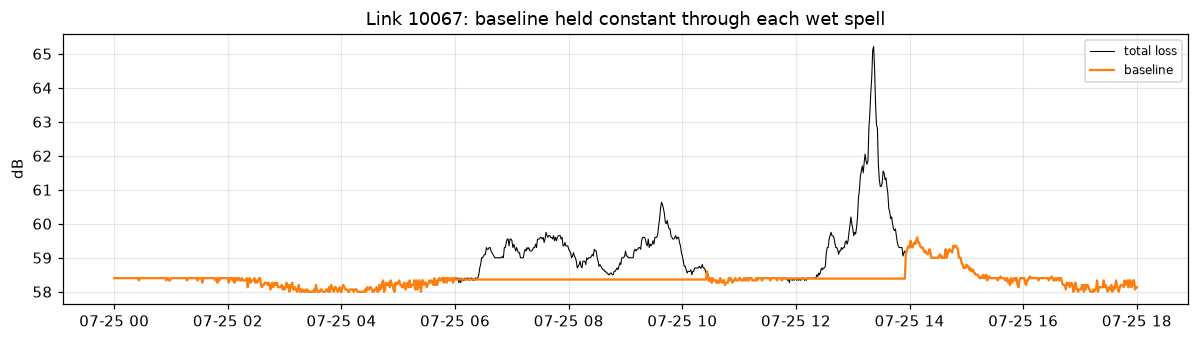

In [9]:
import pycomlink as pycml

one = kept.sel(cml_id=[LINK])
wet = ic.wet_from_radar(one, radar_along, rad_freq=5)
baseline = pycml.processing.baseline.baseline_constant(trsl=one.tl, wet=wet, n_average_last_dry=5)
A_obs = (one.tl - baseline).clip(min=0)

fig, ax = plt.subplots(figsize=(11, 3.2))
s0 = one.sublink_id.values[0]
ax.plot(one.time.sel(time=day), one.tl.sel(sublink_id=s0, time=day).squeeze(), color="k", lw=0.7, label="total loss")
ax.plot(one.time.sel(time=day), baseline.sel(sublink_id=s0, time=day).squeeze(), color="C1", lw=1.5, label="baseline")
ax.set(ylabel="dB", title=f"Link {LINK}: baseline held constant through each wet spell")
ax.legend(fontsize=8)
plt.tight_layout()

## 6. Wet-antenna attenuation

Water on the antenna covers adds attenuation that has nothing to do with rain on the
path - typically 1-3 dB per link once the radomes are wet, independent of path length.
On a short link it can exceed the rain signal itself, so ignoring it overestimates rain
badly at low intensities. Two models from pycomlink:

* **Leijnse et al. (2008)**: a physical model of a thin water film whose thickness grows
  with rain rate; frequency dependent.
* **Pastorek et al. (2021)**: an empirical model in which the wet-antenna attenuation
  saturates with rain rate, $A_{wa} = A_{max}\,(1 - e^{-d R^{\zeta}})$ (after Kharadly &
  Ross, 2001); pycomlink inverts it so that $A_{obs} = A_{rain} + A_{wa}$. The
  intercomparison uses $A_{max}=6$ dB, $\zeta=0.7$, $d=0.15$.

The wet-antenna correction sets the overall magnitude of retrieved rain more than any
other step; in `projects/maps/archive_pipeline` the ratio of retrieved to reference rain
moves from 1.93 to 0.74 across plausible settings.

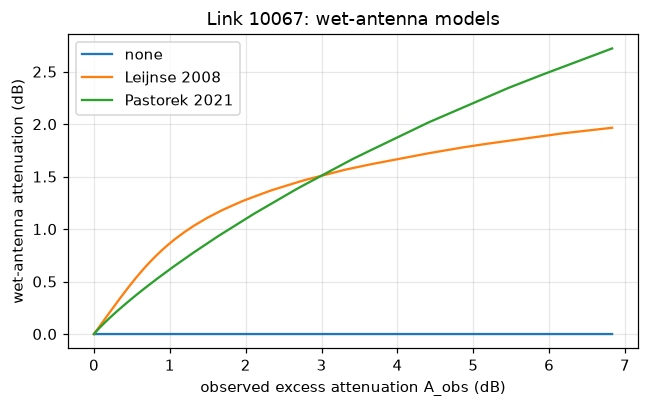

In [10]:
f_hz = one.frequency * 1e6                          # stored in MHz
L_km = one.length / 1000                            # stored in m
waa = {
    "none": xr.zeros_like(A_obs),
    "Leijnse 2008": pycml.processing.wet_antenna.waa_leijnse_2008_from_A_obs(
        A_obs=A_obs, f_Hz=f_hz, pol=one.polarization.data, L_km=L_km),
    "Pastorek 2021": pycml.processing.wet_antenna.waa_pastorek_2021_from_A_obs(
        A_obs=A_obs, f_Hz=f_hz, pol=one.polarization.data, L_km=L_km, A_max=6, zeta=0.7, d=0.15),
}
rain = {}
for name, w in waa.items():
    A = (A_obs - w).clip(min=0)
    rain[name] = pycml.processing.k_R_relation.calc_R_from_A(
        A=A, L_km=L_km.astype(float), f_GHz=one.frequency / 1000, pol=one.polarization)

fig, ax = plt.subplots(figsize=(6, 3.8))
x = A_obs.sel(sublink_id=s0).values.ravel()
order = np.argsort(x)
for name, w in waa.items():
    ax.plot(x[order], w.sel(sublink_id=s0).values.ravel()[order], label=name)
ax.set(xlabel="observed excess attenuation A_obs (dB)", ylabel="wet-antenna attenuation (dB)",
       title=f"Link {LINK}: wet-antenna models")
ax.legend()
plt.tight_layout()

## 7. Rain rate, and how it compares

With the wet antenna removed, the k-R relation gives a rain rate per minute and
sublink. We average the two sublinks and compare with two references: the radar
averaged along the path, and the nearest municipal gauge.

nearest gauge: Askim (Askim Ögärdesv), 1.0 km from the link centre


,"CML, WAA none","CML, WAA Leijnse 2008","CML, WAA Pastorek 2021",radar along path,gauge Askim
event total (mm),11.1,3.2,4.7,8.5,9.2


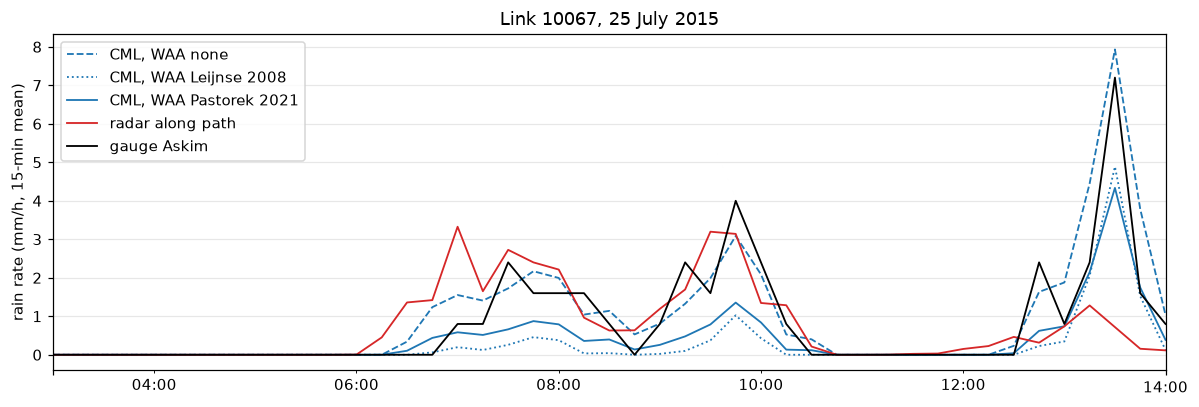

In [11]:
from core.geo import haversine_m

mid_lat = ((one.site_0_lat + one.site_1_lat) / 2).item()
mid_lon = ((one.site_0_lon + one.site_1_lon) / 2).item()
dist = haversine_m(mid_lat, mid_lon, gauges.lat.values, gauges.lon.values)
g_id = gauges.id.values[np.argmin(dist)]
print(f"nearest gauge: {g_id} ({gauges.location.sel(id=g_id).item()}), {dist.min() / 1000:.1f} km from the link centre")

to15 = lambda da: da.resample(time="15min", label="right", closed="right").mean()   # mm/h, 15-min mean
series = {f"CML, WAA {k}": to15(v.mean("sublink_id").squeeze()) for k, v in rain.items()}
series["radar along path"] = to15(radar_along.sel(cml_id=LINK) * 12)                 # mm per 5 min -> mm/h
series["gauge " + g_id] = to15(gauges.R.sel(id=g_id))
df = pd.DataFrame({k: v.to_series() for k, v in series.items()}).loc["2015-07-25 03:00":"2015-07-25 14:00"]

ax = df.plot(figsize=(11, 3.8), lw=1.2,
             style=["C0--", "C0:", "C0-", "C3-", "k-"])
ax.set(ylabel="rain rate (mm/h, 15-min mean)", xlabel="", title=f"Link {LINK}, 25 July 2015")
plt.tight_layout()

event = df.sum() / 4                                         # mm over the window
event.round(1).to_frame("event total (mm)").T

On this link and this storm the uncorrected retrieval is the closest to both
references, and both wet-antenna models remove too much - the opposite of what they
were designed to fix. The models were fitted on other links and other climates; their
parameters do not transfer reliably, which is why `projects/maps/archive_pipeline` finds
the wet-antenna setting to be the step that most changes the magnitude of retrieved
rain. Neither reference is exact either: the radar measures a 2 x 2 km volume several
hundred metres aloft, and the gauge is a point about a kilometre from the path. That
three-way disagreement is the normal situation in this field, and why FieldSense scores
everything against more than one reference.

## 8. The whole network

`ic.chain` runs all of the above - QC, radar wet/dry, baseline, Pastorek wet antenna,
k-R - on every link and returns hour-ending link totals (mm), the input of the merging
methods in Tutorials 5 and 6.

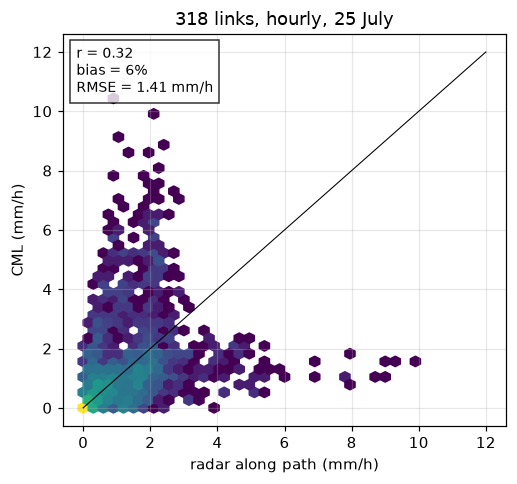

In [12]:
hourly_links, removed_ids = ic.chain(cml, radar_along, rad_freq=5)
radar_hourly = ic.hourly_from_mean(radar_along, steps_per_hour=12)
pair = xr.align(hourly_links.sel(time="2015-07-25").transpose("cml_id", "time"),
                radar_hourly.sel(time="2015-07-25").transpose("cml_id", "time"), join="inner")
x, y = pair[1].values.ravel(), pair[0].values.ravel()
ok = np.isfinite(x) & np.isfinite(y)

import poligrain as plg

metrics = plg.validation.calculate_rainfall_metrics(reference=x[ok], estimate=y[ok], ref_thresh=0.1, est_thresh=0.1)
fig, ax = plt.subplots(figsize=(4.8, 4.5))
ax.hexbin(x[ok], y[ok], gridsize=40, bins="log", extent=(0, 12, 0, 12), mincnt=1, cmap="viridis")
ax.plot([0, 12], [0, 12], "k-", lw=0.7)
ax.set(xlabel="radar along path (mm/h)", ylabel="CML (mm/h)",
       title=f"{len(np.unique(pair[0].cml_id))} links, hourly, 25 July")
ax.text(0.03, 0.97, f"r = {metrics['pearson_correlation_coefficient']:.2f}\n"
        f"bias = {metrics['percent_bias']:.0f}%\nRMSE = {metrics['root_mean_square_error']:.2f} mm/h",
        transform=ax.transAxes, va="top", fontsize=9, bbox=dict(fc="w", alpha=0.8))
plt.tight_layout()

Agreement is modest: one storm, quality control on two days of record, and a
2-km radar compared with paths as short as a few hundred metres. Because the wet/dry
mask comes from the radar, the comparison even flatters the links (they cannot report
rain where the radar saw none). The OpenSense example subset also
carries the reference retrieval published with the data (variable `R`), and
`projects/maps/archive_pipeline/src/validate_retrieval.py` compares FieldSense's chain
with it.

## 9. Where this is used in FieldSense

| module / project | what it adds |
|---|---|
| `core.opensense.retrieval` | the configurable chain (rolling-std wet/dry, rolling-median baseline, four wet-antenna models) used by `opensense_pipeline` |
| `core.opensense.intercomparison_chain` | the chain used here, as in the OpenSense radar-adjustment intercomparison |
| `core.cml` | estimators for the hourly studies (dynamic baseline, nearby links, PyNNcml RNN) |
| `projects/retrieval/openmrg` | model-driven chain vs a two-step RNN on OpenMRG |
| `projects/retrieval/rnn_three_networks` | the RNN trained on three networks ([Tutorial 3](03_training_a_retrieval_network.ipynb)) |

**Next:** [Tutorial 3](03_training_a_retrieval_network.ipynb) replaces the power law
with a trained network.

## 10. References and links

* Atlas, D., and Ulbrich, C. W. (1977). Path- and area-integrated rainfall measurement by microwave attenuation in the 1-3 cm band. *J. Appl. Meteor.*, 16, 1322-1331. [doi:10.1175/1520-0450(1977)016<1322:PAAIRM>2.0.CO;2](https://doi.org/10.1175/1520-0450(1977)016<1322:PAAIRM>2.0.CO;2)
* ITU-R (2005). Recommendation P.838-3: Specific attenuation model for rain for use in prediction methods. [itu.int/rec/R-REC-P.838-3-200503-I](https://www.itu.int/rec/R-REC-P.838-3-200503-I/en)
* Kharadly, M. M. Z., and Ross, R. (2001). Effect of wet antenna attenuation on propagation data statistics. *IEEE Trans. Antennas Propag.*, 49, 1183-1191. [doi:10.1109/8.943313](https://doi.org/10.1109/8.943313)
* Leijnse, H., Uijlenhoet, R., and Stricker, J. N. M. (2008). Microwave link rainfall estimation: effects of link length and frequency, temporal sampling, power resolution, and wet antenna attenuation. *Adv. Water Resour.*, 31, 1481-1493. [doi:10.1016/j.advwatres.2008.03.004](https://doi.org/10.1016/j.advwatres.2008.03.004)
* Overeem, A., Leijnse, H., and Uijlenhoet, R. (2016). Retrieval algorithm for rainfall mapping from microwave links in a cellular communication network. *Atmos. Meas. Tech.*, 9, 2425-2444. [doi:10.5194/amt-9-2425-2016](https://doi.org/10.5194/amt-9-2425-2016)
* Pastorek, J., Fencl, M., Rieckermann, J., and Bareš, V. (2021). Precipitation estimates from commercial microwave links: practical approaches to wet-antenna correction. *IEEE Trans. Geosci. Remote Sens.*, 60, 1-9. [doi:10.1109/TGRS.2021.3110004](https://doi.org/10.1109/TGRS.2021.3110004)
* Polz, J., Chwala, C., Graf, M., and Kunstmann, H. (2020). Rain event detection in commercial microwave link attenuation data using convolutional neural networks. *Atmos. Meas. Tech.*, 13, 3835-3853. [doi:10.5194/amt-13-3835-2020](https://doi.org/10.5194/amt-13-3835-2020)
* Schleiss, M., and Berne, A. (2010). Identification of dry and rainy periods using telecommunication microwave links. *IEEE Geosci. Remote Sens. Lett.*, 7, 611-615. [doi:10.1109/LGRS.2010.2043052](https://doi.org/10.1109/LGRS.2010.2043052)
* Software: [pycomlink](https://github.com/pycomlink/pycomlink) ([docs](https://pycomlink.readthedocs.io)), [poligrain](https://github.com/OpenSenseAction/poligrain) ([docs](https://poligrain.readthedocs.io)), [radar_adjustment_intercomparison](https://github.com/OpenSenseAction/radar_adjustment_intercomparison)